In [7]:
# This should give version 1.3.3dev!
import sys
sys.path.insert(0,'/home/user/Bbarolo')

from pyBBarolo import version
print (version)
from pyBBarolo.BB_interface import libBB
from pyBBarolo.bayesian import BayesianBBarolo
import ctypes, time, copy
from pyBBarolo import Param, Rings, FitMod3D, reshapePointer, vprint, isIterable
import numpy as np
from pyBBarolo.bayesian import BayesianBBarolo
from dynesty import plotting as dyplot
import matplotlib.pyplot as plt
import numpy as np
from multiprocessing import Pool
import corner


parallel=True
try: 
    from schwimmbad import MultiPool, MPIPool
    from mpi4py import MPI
except ImportError:
    print ("WARNING! Parallelization is disabled. Please install schwimmbad and mpi4py to enable it.")
    parallel = False

try: 
    import dynesty as dyn
    from dynesty.utils import resample_equal
except ImportError:
    raise ImportError("BayesianBB requires the package 'dynesty'. Please install it.")


class BayesianBBaroloMod(BayesianBBarolo):

    def __init__(self,fitsname,**kwargs):
        """ Initialize the BayesianBBarolo class.
    
        Parameters
        ----------
        fitsname : str
            The name of the fits file with the datacube to fit.
        **kwargs : dict
            Any other parameter to be passed to the BBarolo's library.
        """

        super(BayesianBBaroloMod,self).__init__(fitsname,**kwargs)
        self.noise=None
        self.Npix=None

    def _calculate_model(self,rings):
            """ This function calculates a unnormalized model given a set of rings.
            
                Parameters
                ----------
                rings : Rings
                    A Rings object with the parameters of the model.
    
                Returns
                -------
                mod : 3D array
                    A 3D array with the model.
                bhi, blo : 1D arrays
                    The boundaries of the model in the input cube.
                galmod : pointer 
                    A pointer to the Galmod object. Need to be freed after use.
            """
            # Model is built in a smaller array (blo,bhi) that only contains the galaxy 
            # within the last ring. This is to calculate the residuals faster.
            _, ys, xs = self.data.shape
            bhi, blo = (ctypes.c_int * 2)(xs,ys), (ctypes.c_int * 2)(0)
            #libBB.Galfit_getModelSize(self._galfit,rings._rings,bhi,blo)
            galmod = libBB.Galfit_getModel(self._galfit,rings._rings,bhi,blo)
            bhi, blo = np.array(bhi), np.array(blo)
            # Reshaping the model to the correct 3D shape
            mod_shape = (self.inp.dim[-1], bhi[1]-blo[1],bhi[0]-blo[0])
            mod = reshapePointer(libBB.Galmod_array(galmod),self.data.shape)

    
            return mod, bhi, blo, galmod



    def _log_likelihood(self,theta):
        """ Likelihood function for the fit """
        rings = self._update_rings(self._inri,theta)


        # Calculating residuals manually            

        # Recompute the density profile along the current rings and update the rings
        if self.useNorm and self.update_prof:
            self._update_profile(rings)

        # Calculate the model and the boundaries
        mod, bhi, blo, galmod = self._calculate_model(rings)

        
        # Calculate likelihood 
        if self.noise is None: self.noise=np.nanstd(self.data[0,:,:])
        if self.Npix is None:  self.Npix=np.prod(self.data.shape)
        
        mod = self._normalize_model(mod,self.data)
        #Gaulkl = -1000*np.nansum(np.abs(self.data-mod)) #version A
        #Gaulkl = -1000*np.nansum(np.abs(self.data-mod))/self.noise #version B
        Gaulkl = -np.nansum((self.data-mod)**2)/(self.noise**2) #version C
        #Gaulkl = -np.nansum((self.data-mod)**2) #version D
        #Gaulkl = -1000*np.nansum((self.data-mod)**2) #version E
        #Gaulkl = -1000*np.nansum((self.data-mod)**2)/(self.noise**2) #version F

        libBB.Galmod_delete(galmod)
            
        return Gaulkl
    


    def _log_likelihood2(self,theta):
        """ Likelihood function for the fit """

        
        rings = self._update_rings(self._inri,theta)

        if True:
            # Calculating residuals through BBarolo directly
            res = libBB.Galfit_calcresiduals(self._galfit,rings._rings)
        else: 
            # Calculating residuals manually            

            # Recompute the density profile along the current rings and update the rings
            if self.useNorm and self.update_prof:
                self._update_profile(rings)

            # Calculate the model and the boundaries
            mod, bhi, blo, galmod = self._calculate_model(rings)
            
            # Calculate the residuals
            mask = self.mask[:,blo[1]:bhi[1],blo[0]:bhi[0]]
            data = self.data[:,blo[1]:bhi[1],blo[0]:bhi[0]]
            res  = self._calculate_residuals(mod,data,mask)

            libBB.Galmod_delete(galmod)
            
        return -1000*res

    def _normalize_model(self,model,data):
        """ This is the default normalization function for the model. 
            It can be overwritten by the user if needed.
        """
        # Normalizing the model to the maximum value of the data
        nrm = np.nansum(data)/np.nansum(model)
        return nrm*model
       

1.3.3dev


HEADER WARNING: TELESCOP-INSTRUME keywords not found.

Opening file /home/user/THESIS/MODELS_THESIS/CGal_4_70_0.01/CGal_4_70_0.01.fits
Reading 51 x 51 x 64 pixels FITS file (0.6 MB)... Done. 



100%|██████████| 8000/8000 [4:44:55<00:00,  2.14s/it]   


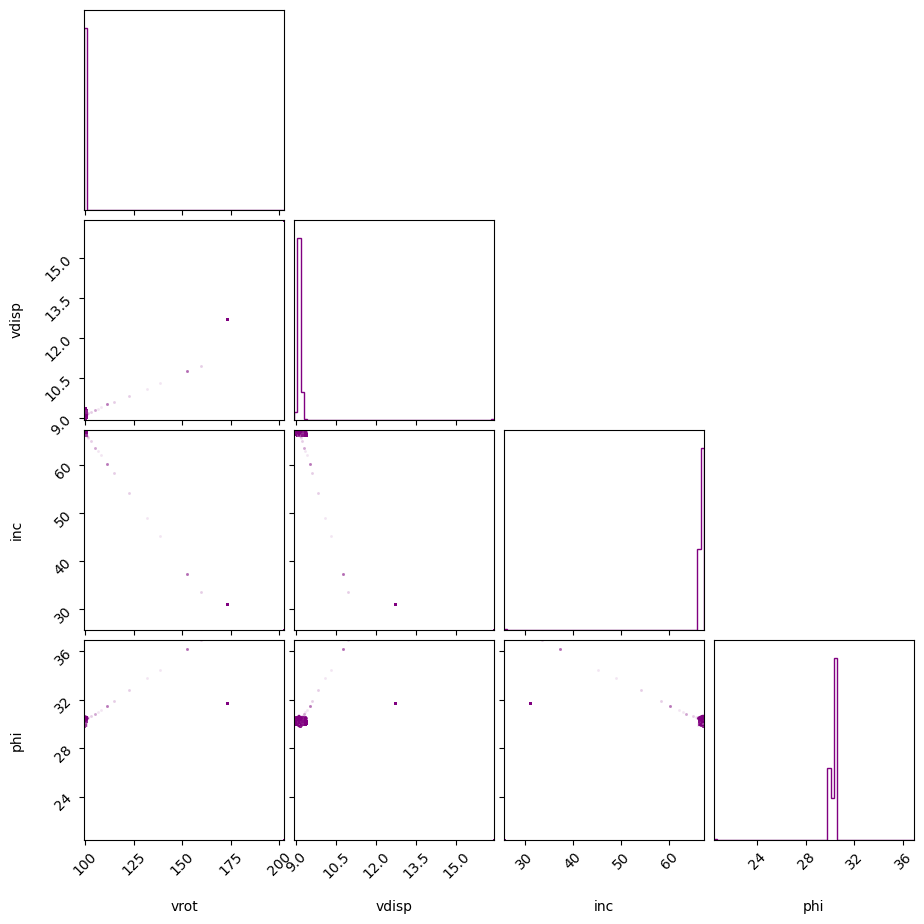

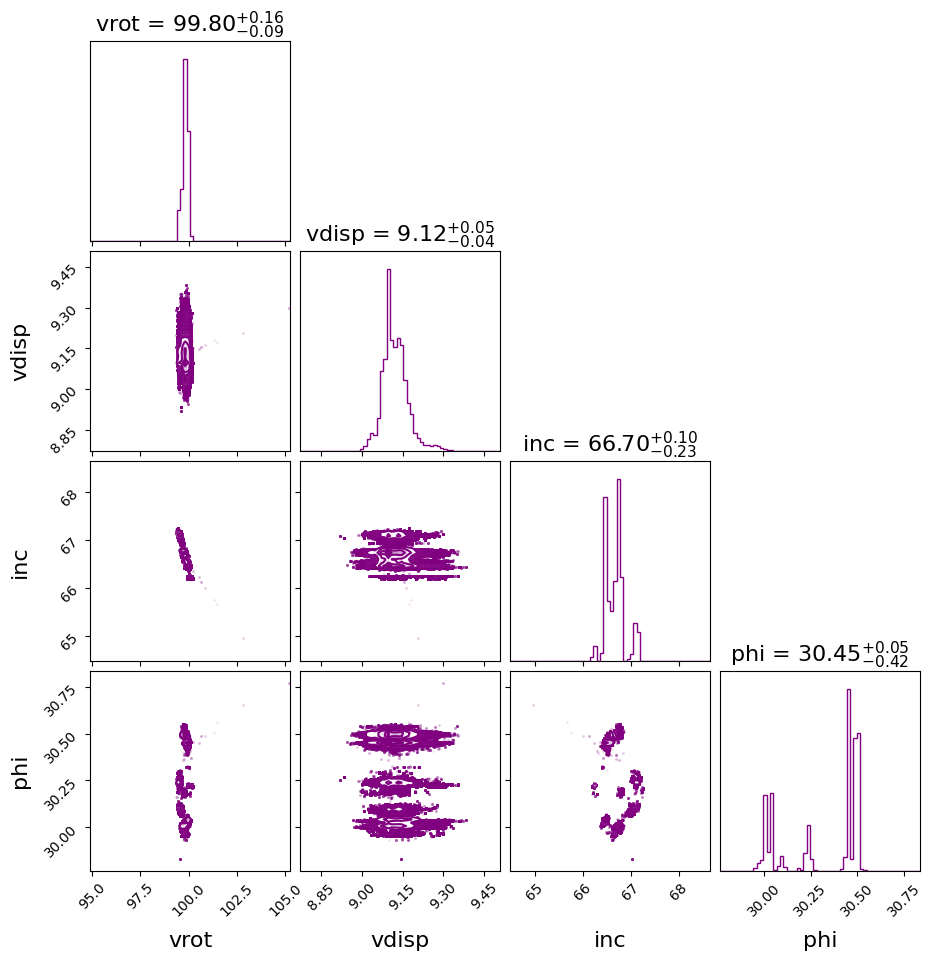

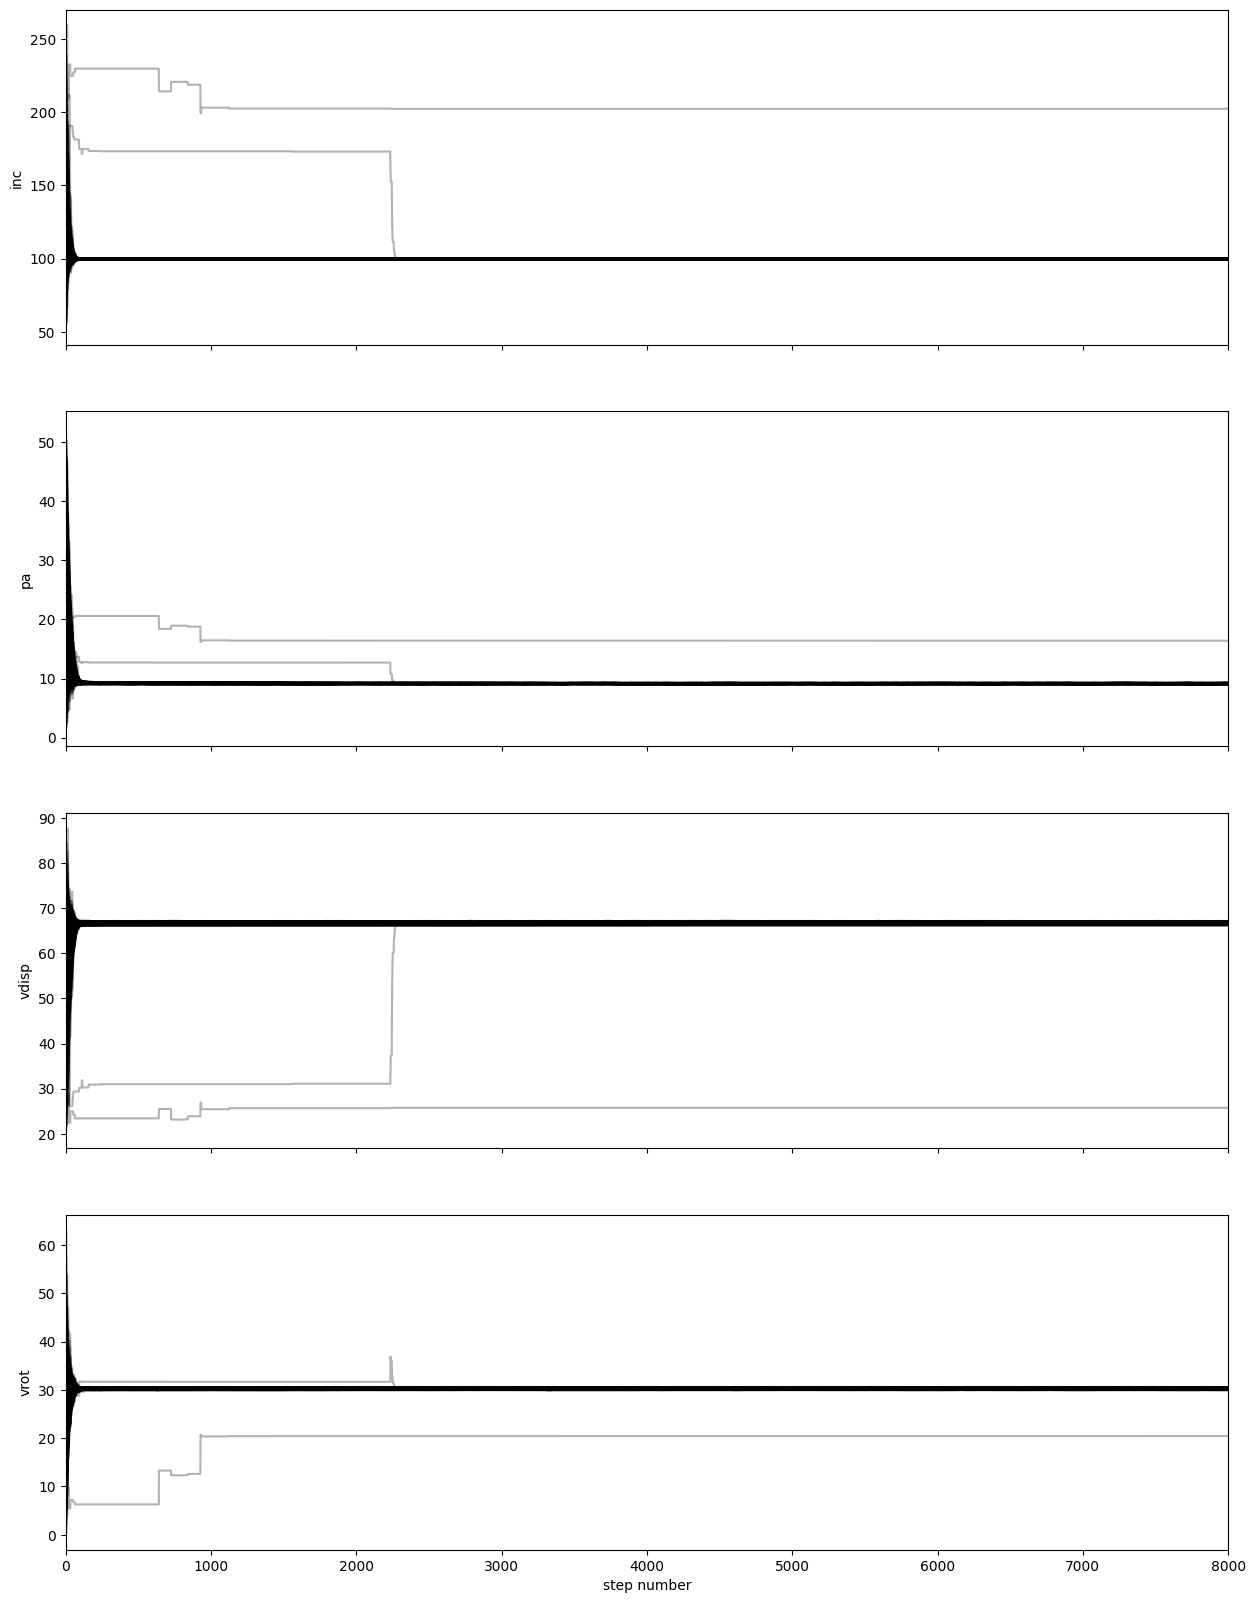

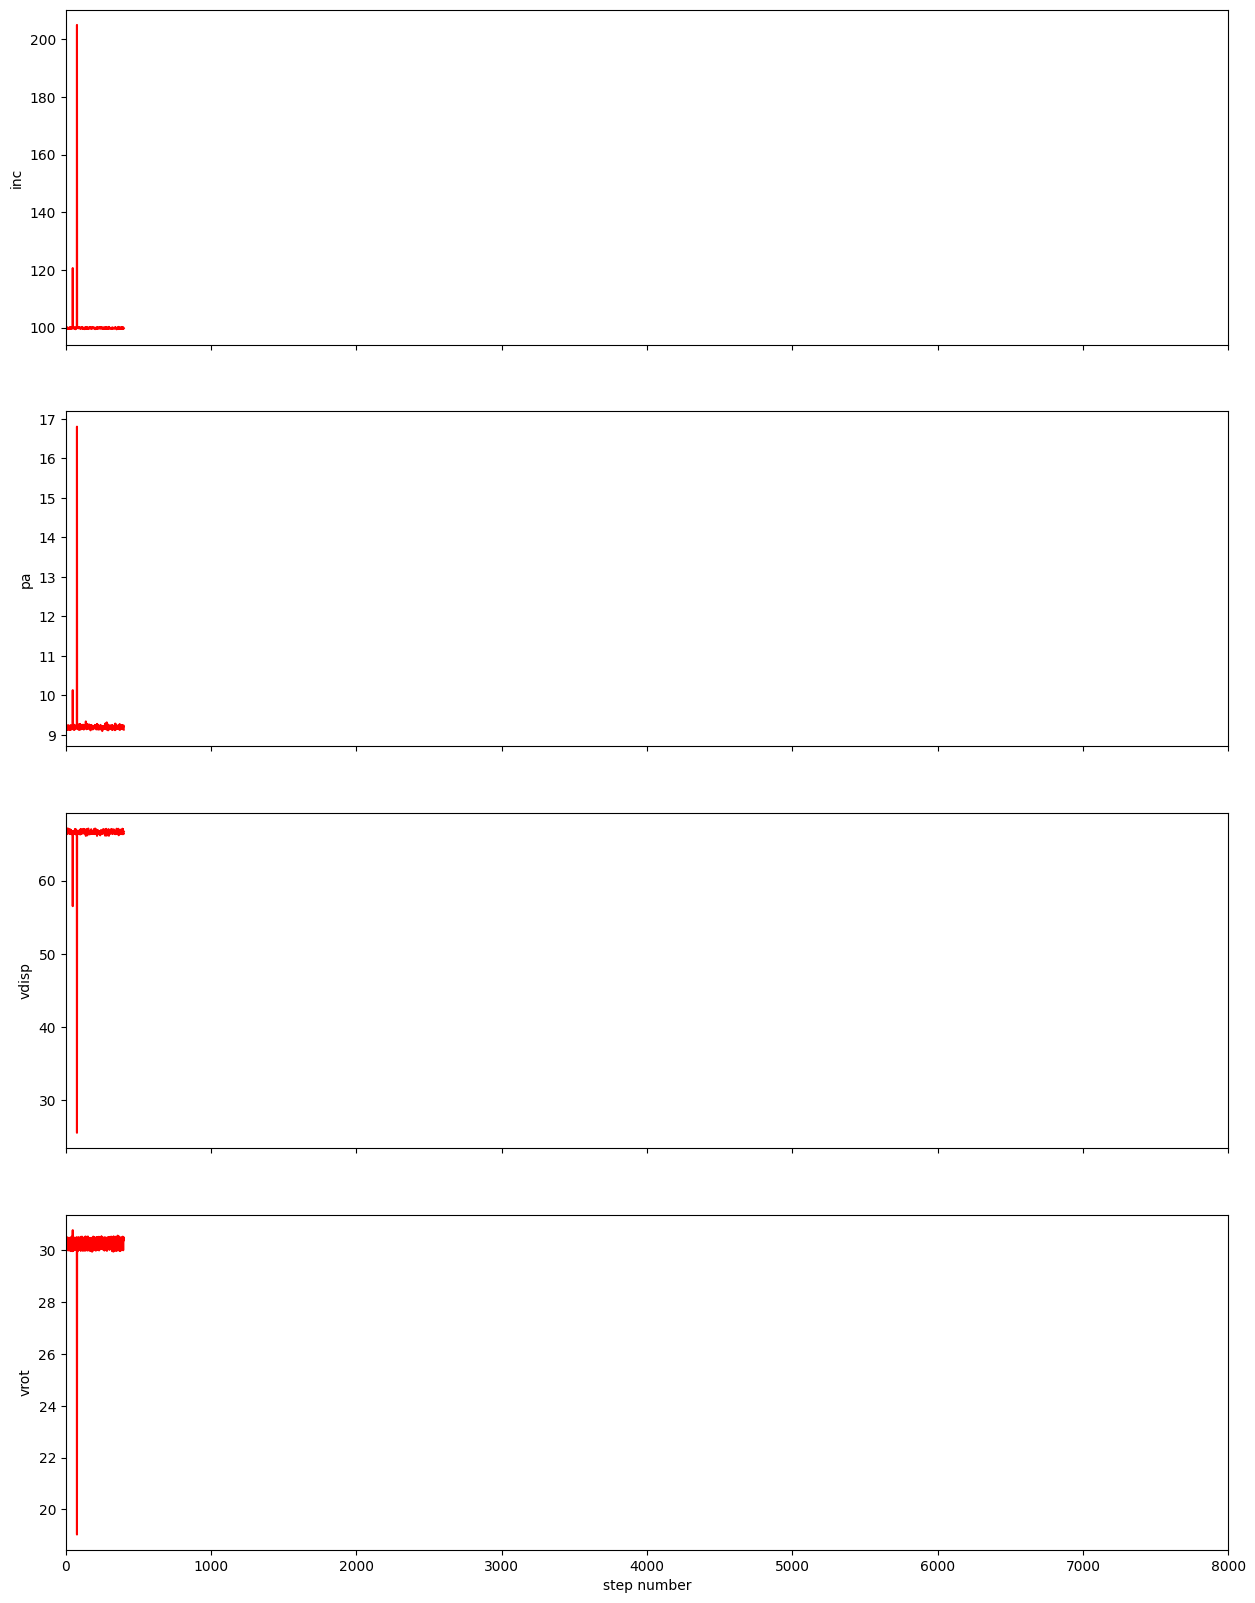

In [8]:
#Try with mcmc 
import emcee
model = "CGal_4_70_0.01_emcee_single_C_8000"
threads = 8
fitsname = f"/home/user/THESIS/MODELS_THESIS/CGal_4_70_0.01/CGal_4_70_0.01.fits"
ringfile = f"/home/user/THESIS/MODELS_THESIS/CGal_4_70_0.01/CGal_4_70_0.01_params.txt"
output = "/home/user/THESIS/new_tests_single/new_tests_emcee_single"
freepar = ["vrot_single","vdisp_single", "inc_single", "phi_single"]


#f3d = BayesianBBarolo(fitsname)
#th  = multiprocessing.cpu_count() #this counts my cpu so that the code can run with all of them


tabinp=np.loadtxt(ringfile)
rad = tabinp[:,0] 
xpos= tabinp[0,8] 
ypos= tabinp[0,9]
vsys= tabinp[0,10]
vrad= tabinp[:,2]
z0=  tabinp[0,6]
inc= tabinp[0,4]
pa= tabinp[0,5]
vrot= tabinp[:,1]
vdisp= tabinp[:,3]
dens=tabinp[:,7]


# Creating an object for bayesian barolo
f3d = BayesianBBaroloMod(fitsname)

# Initializing rings. 
f3d.init(radii=rad,xpos=xpos,ypos=ypos,vsys=0.0,\
         vrot=vrot,vdisp=vdisp,vrad=vrad,z0=z0,inc=inc,phi=pa,dens=dens)

# Here it is possible to give any other BBarolo parameter, for example to control
# the mask, linear, bweight, cdens, wfunc, etc...
f3d.set_options(mask="SEARCH",linear=0,outfolder=f"{output}/{model}",plotmask=True)
# Setting up all the needed class attributes
f3d._setup(freepar,useBBres=False)

def likelihood(theta):

    #cosinc,pa, vdisp1, vdisp2, vdisp3, vdisp4, vrot1, vrot2,vrot3, vrot4= theta
    #if cosinc<0 or cosinc>1 or pa<-np.pi or pa>np.pi or vdisp1 < 0.1 or vdisp1 > 100 or vdisp2 < 0.1 or vdisp2 > 100 or vdisp3 < 0.1 or vdisp3 > 100 or vdisp4 < 0.1 or vdisp4 > 100 or vrot1 < 0 or vrot1 > 300 or vrot2 < 0 or vrot2 > 300 or vrot3 < 0 or vrot3 > 300 or vrot4 < 0 or vrot4 > 300:

    vrot, vdisp,inc,pa =theta
    if inc<0 or inc>90 or pa<0 or pa>360 or vdisp < 0.1 or vdisp > 100 or vrot < 0 or vrot > 300:
        return -np.inf,  -np.inf 

    #thetain=np.array([np.degrees(np.arccos(cosinc)),np.degrees(pa),vdisp1, vdisp2, vdisp3, vdisp4, vrot1, vrot2, vrot3, vrot4])
    thetain=np.array([vrot,vdisp,inc,pa])
    ll = f3d._log_likelihood(thetain)
    
    if np.isfinite(ll): return ll, ll
    else: return -np.inf,  -np.inf 


ndim, nwalkers = 4, 400

p0=np.zeros(shape=(nwalkers,ndim))
#p0[:,0]=np.random.uniform(1,100,size=nwalkers)
p0[:,0]=np.random.uniform(50,200,size=nwalkers)
p0[:,1]=np.random.uniform(1,50,size=nwalkers)
p0[:,2]=np.random.uniform(20,80,size=nwalkers)
p0[:,3]=np.random.uniform(0,50,size=nwalkers)
#p0[:,4]=np.random.uniform(10,50,size=nwalkers)
#p0[:,5]=np.random.uniform(10,50,size=nwalkers) 
#p0[:,6]=np.random.uniform(0,200,size=nwalkers)
#p0[:,7]=np.random.uniform(0,200,size=nwalkers)
#p0[:,8]=np.random.uniform(0,200,size=nwalkers)
#p0[:,9]=np.random.uniform(0,200,size=nwalkers) 


labels = ["vrot","vdisp","inc","phi"]
#labels = ["inc","pa","vdisp1", "vdisp2","vdisp3", "vdisp4","vrot1","vrot2","vrot3","vrot4"]

with Pool(8) as pool:
    sampler = emcee.EnsembleSampler(nwalkers, ndim, likelihood, pool=pool)
    sampler.run_mcmc(p0, 8000, progress=True)

""" samples = sampler.get_chain()
np.save(f"{output}/{model}/all_samples.npy", samples)
log_prob_samples = sampler.get_log_prob()
np.save(f"{output}/{model}/all_logprob.npy", log_prob_samples)

# We'll track how the average autocorrelation time estimate changes
max_n = 300
index = 0
autocorr = np.empty(max_n)

# This will be useful to testing convergence
old_tau = np.inf

# Now we'll sample for up to max_n steps
for sample in sampler.sample(p0, iterations=max_n, progress=True):   
    # Only check convergence every 100 steps
    if sampler.iteration % 30 != 0:
        continue

    # Compute the autocorrelation time so far
    # Using tol=0 means that we'll always get an estimate even
    # if it isn't trustworthy
    tau = sampler.get_autocorr_time(tol=0)
    autocorr[index] = np.mean(tau)
    index += 1

    # Check convergence
    converged = np.all(tau * 100 < sampler.iteration)
    converged &= np.all(np.abs(old_tau - tau) / tau < 0.01)
    if converged:
        break
    old_tau = tau

# OUTOCORRELATION TIME

n = 100 * np.arange(1, index + 1)
y = autocorr[:index]
plt.plot(n, n / 100.0, "--k")
plt.plot(n, y)
plt.xlim(0, n.max())
plt.ylim(0, y.max() + 0.1 * (y.max() - y.min()))
plt.xlabel("number of steps")
plt.ylabel(r"mean $\hat{\tau}$")

plt.savefig(f'{output}/{model}/{model}_correlation.pdf',bbox_inches='tight')
 """

#CORNER PLOT
all_samples = sampler.get_chain()
np.save(f"{output}/{model}_samples.npy", all_samples)

flat_samples = sampler.get_chain(flat=True,discard=2000)
means = np.mean(flat_samples, axis=0)
stds = np.std(flat_samples, axis=0)
ranges = [(mean - std, mean + std) for mean, std in zip(means, stds)]
fig1 = corner.corner(flat_samples, color = "purple",bins = 60, labels=labels)


plt.show()
fig1.savefig(f'{output}/{model}_corner.pdf',bbox_inches='tight')

fig2 = corner.corner(flat_samples, bins = 60,show_titles=True,
                     title_kwargs={"fontsize": 16}, label_kwargs={"fontsize": 16}, tick_params={"labelsize": 14}, labels=labels, color='purple',plot_datapoints=True, 
                     range=ranges)

plt.show()
fig2.savefig(f'{output}/{model}_corner_new.pdf',bbox_inches='tight')

#TRACING PLOT

fig, axes = plt.subplots(4, figsize=(15, 20), sharex=True)
samples = sampler.get_chain()
labels = ["inc","pa","vdisp","vrot"]
#labels = ["inc","pa","vdisp1", "vdisp2","vdisp3", "vdisp4","vrot1","vrot2","vrot3","vrot4"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])

axes[-1].set_xlabel("step number")
plt.show()
fig.savefig(f'{output}/{model}_tracing.pdf',bbox_inches='tight')

#MEAN TRACING PLOT

fig, axes = plt.subplots(4, figsize=(15, 20), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i].mean(axis=0), "r")
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])

axes[-1].set_xlabel("step number")
plt.show()
fig.savefig(f'{output}/{model}_mean_tracing.pdf',bbox_inches='tight')
#xx=np.linspace(0,1,100)

#ll=[]
#for x in xx:
#    ll.append(likelihood(x))


#import matplotlib.pyplot as plt
#plt.plot(np.degrees(np.arccos(xx)),ll)
#plt.show() 






    

In [9]:
#import corner
#flat_samples = sampler.get_chain(flat=True,discard=10)
#fig = corner.corner(flat_samples, labels=["vrot","vdisp","inc","pa"], truths=[100,10,np.cos(np.radians(70)),np.radians(0)])
#fig.savefig(f'{output}/{model}/{model}_corner.pdf',bbox_inches='tight')

In [10]:
np.cos(np.radians(70))

np.float64(0.3420201433256688)